In [18]:
import sqlite3
import pandas as pd

# Criar o banco de dados
conn = sqlite3.connect("lh_nautical.db")
print("Banco de dados criado")

Banco de dados criado


In [19]:
df_vendas = pd.read_csv("vendas_limpo.csv")
df_produtos = pd.read_csv("produtos_limpo.csv")
df_clientes = pd.read_csv("clientes_limpo.csv")
df_custos = pd.read_csv("custos_resumido.csv")

print("CSVs carregados!")

FileNotFoundError: [Errno 2] No such file or directory: 'vendas_limpo.csv'

In [ ]:
df_vendas.to_sql("vendas", conn, if_exists="replace", index=False)
df_produtos.to_sql("produtos", conn, if_exists="replace", index=False)
df_clientes.to_sql("clientes", conn, if_exists="replace", index=False)
df_custos.to_sql("custos", conn, if_exists="replace", index=False)

print("Tabelas criadas no banco!")

✅ Tabelas criadas no banco!


In [12]:
query = "SELECT name FROM sqlite_master WHERE type='table'"
tabelas = pd.read_sql(query, conn)
print("Tabelas no banco:")
print(tabelas)

Tabelas no banco:
Empty DataFrame
Columns: [name]
Index: []


In [ ]:
query = """
SELECT
    v.id,
    v.qtd,
    v.total,
    v.sale_date,
    p.name,
    p.actual_category,
    p.price,
    c.full_name,
    c.cidade,
    c.estado,
    cu.custo_atual_usd

FROM vendas v
LEFT JOIN produtos p ON v.id_product = p.code
LEFT JOIN clientes c ON v.id_client = c.code
LEFT JOIN custos cu ON v.id_product = cu.product_id

LIMIT 10
"""

df_completo = pd.read_sql(query, conn)
print("Consulta funcionando!")
df_completo.head()

✅ Consulta funcionando!


,id,qtd,total,sale_date,name,actual_category,price,full_name,cidade,estado,custo_atual_usd
0,0,11,3405.0,2023-09-10,Cabo De Nylon Danforth Prime,Ancoragem,309.54,Márcia Figueiredo,Vila Do Conde,PA,53.37
1,1,9,16873.9,2024-09-15,Cabo De Nylon Bruce Flux Hydro,Ancoragem,1973.50,Daniel Farias Ribeiro Teixeira,Rio Grande,RS,390.62
2,2,7,9475.3,2024-08-13,Boia De Arqueamento Danforth Torque,Ancoragem,1424.88,Femininos Antunes Lopes Ribeiro Amaral,São Mateus,ES,246.89
3,4,5,55893.0,2023-02-03,Piloto Automático Furuno Torque Peak,Eletronicos,11178.63,Bruno Silva,Santarém Novo,PA,2244.66
4,5,4,451403.9,2024-02-12,Motor De Popa Honda Vector Kinetic 174Hp,Propulsao,118790.57,Luiz Alves Pimentel,Aracaju,SE,20486.78


In [ ]:
# Criar a tabela completa no banco
query_completo = """
CREATE TABLE IF NOT EXISTS base_completa AS
SELECT
    v.id,
    v.id_client,
    v.id_product,
    v.qtd,
    v.total,
    v.sale_date,
    p.name,
    p.actual_category,
    p.price,
    c.full_name,
    c.cidade,
    c.estado,
    cu.custo_atual_usd

FROM vendas v
LEFT JOIN produtos p ON v.id_product = p.code
LEFT JOIN clientes c ON v.id_client = c.code
LEFT JOIN custos cu ON v.id_product = cu.product_id
"""

conn.execute(query_completo)
conn.commit()
print("Tabela base_completa criada no banco!")

## Como fica a estrutura do banco
```
#lh_nautical.db
#├── vendas
#├── produtos
#├── clientes
#├── custos
#└── base_completa

✅ Tabela base_completa criada no banco!


In [ ]:
conn.close()

✅ Conexão fechada!


In [31]:
import sqlite3
import pandas as pd
conn = sqlite3.connect("lh_nautical.db")

In [24]:
query = "SELECT name FROM sqlite_master WHERE type='table'"
tabelas = pd.read_sql(query, conn)
print("Tabelas disponíveis:")
print(tabelas)

Tabelas disponíveis:
            name
0         vendas
1       produtos
2       clientes
3         custos
4  base_completa


In [32]:
# Carregar do banco
df_base_completa = pd.read_sql("SELECT * FROM base_completa", conn)

# Salvar como CSV
df_base_completa.to_csv("base_completa.csv", index=False)

print(f"Total de linhas: {len(df_base_completa)}")
print(f"Colunas: {df_base_completa.columns.tolist()}")

✅ Arquivo salvo!
Total de linhas: 9895
Colunas: ['id', 'id_client', 'id_product', 'qtd', 'total', 'sale_date', 'name', 'actual_category', 'price', 'full_name', 'cidade', 'estado', 'custo_atual_usd']


In [ ]:
query = """
SELECT
    strftime('%Y', sale_date) AS ano,
    ROUND(SUM(total), 2) AS faturamento_total,
    COUNT(*) AS total_vendas,
    ROUND(AVG(total), 2) AS ticket_medio

FROM base_completa
GROUP BY ano
ORDER BY ano
"""

df_fat_ano = pd.read_sql(query, conn)
df_fat_ano["faturamento_total"] = df_fat_ano["faturamento_total"].apply(lambda x: f"R$ {x:,.2f}")
df_fat_ano["ticket_medio"] = df_fat_ano["ticket_medio"].apply(lambda x: f"R$ {x:,.2f}")
print("FATURAMENTO POR ANO")
print(df_fat_ano.to_string(index=False))

💰 FATURAMENTO POR ANO
 ano   faturamento_total  total_vendas  ticket_medio
2023 R$ 1,288,827,294.55          4991 R$ 258,230.27
2024 R$ 1,321,452,216.15          4904 R$ 269,464.16


In [3]:
query = """
SELECT
    strftime('%Y', sale_date) AS ano,
    strftime('%m', sale_date) AS mes,
    ROUND(SUM(total), 2) AS faturamento_total,
    COUNT(*) AS total_vendas

FROM base_completa
GROUP BY ano, mes
ORDER BY ano, mes
"""

df_fat_mensal = pd.read_sql(query, conn)
df_fat_mensal["faturamento_total"] = df_fat_mensal["faturamento_total"].apply(lambda x: f"R$ {x:,.2f}")
print("FATURAMENTO MENSAL")
print(df_fat_mensal.to_string(index=False))

FATURAMENTO MENSAL
 ano mes faturamento_total  total_vendas
2023  01 R$ 106,814,576.05           427
2023  02 R$ 101,326,437.45           371
2023  03 R$ 106,877,304.25           404
2023  04 R$ 106,534,001.60           426
2023  05 R$ 108,860,270.05           460
2023  06  R$ 98,210,393.50           398
2023  07  R$ 93,793,677.85           427
2023  08 R$ 109,522,514.35           400
2023  09 R$ 103,837,062.85           410
2023  10 R$ 102,358,966.25           391
2023  11 R$ 121,452,750.60           437
2023  12 R$ 129,239,339.75           440
2024  01 R$ 100,632,486.50           394
2024  02 R$ 122,628,581.95           393
2024  03 R$ 108,852,892.40           417
2024  04 R$ 100,314,752.20           407
2024  05  R$ 95,783,102.45           394
2024  06  R$ 99,834,954.75           407
2024  07 R$ 113,051,088.25           397
2024  08 R$ 118,909,475.10           441
2024  09 R$ 108,665,582.05           404
2024  10 R$ 127,579,906.60           449
2024  11 R$ 123,462,499.35           4

In [7]:
query = """
SELECT
    name AS produto,
    actual_category AS categoria,
    SUM(qtd) AS total_qtd,
    ROUND(SUM(total), 2) AS total_faturado

FROM base_completa
GROUP BY name, actual_category
ORDER BY total_faturado DESC
LIMIT 10
"""

df_top_produtos = pd.read_sql(query, conn)
df_top_produtos["total_faturado"] = df_top_produtos["total_faturado"].apply(lambda x: f"R$ {x:,.2f}")
print("TOP 10 PRODUTOS")
print(df_top_produtos.to_string(index=False))

TOP 10 PRODUTOS
                                             produto categoria  total_qtd   total_faturado
                       Motor Diesel Honda Aero 205Hp Propulsao        578 R$ 83,539,339.40
                 Motor Elétrico Torqeedo Pulse 300Hp Propulsao        641 R$ 81,567,066.65
        Motor De Popa Torqeedo Core Hydra Flux 162Hp Propulsao        497 R$ 69,554,254.80
          Motor Elétrico Torqeedo Ion Orca Vox 186Hp Propulsao        505 R$ 68,817,185.90
                       Motor De Popa Volvo Maré 69Hp Propulsao        533 R$ 67,332,086.05
         Motor Elétrico Tohatsu Zenith Oceanic 113Hp Propulsao        506 R$ 66,829,268.70
                 Motor De Popa Yamaha Evo Dash 155Hp Propulsao        556 R$ 65,859,716.10
Motor Elétrico Torqeedo Barracuda Magnum Helix 101Hp Propulsao        538 R$ 64,195,127.60
                Motor De Popa Volvo Hydro Dash 256Hp Propulsao        647 R$ 63,057,815.65
               Motor Diesel Volvo Flow Oceanic 259Hp Propulsao        569 

In [8]:
query = """
SELECT
    actual_category AS categoria,
    SUM(qtd) AS total_qtd,
    ROUND(SUM(total), 2) AS total_faturado,
    ROUND(AVG(total), 2) AS ticket_medio

FROM base_completa
GROUP BY actual_category
ORDER BY total_faturado DESC
"""

df_categorias = pd.read_sql(query, conn)
df_categorias["total_faturado"] = df_categorias["total_faturado"].apply(lambda x: f"R$ {x:,.2f}")
df_categorias["ticket_medio"] = df_categorias["ticket_medio"].apply(lambda x: f"R$ {x:,.2f}")
print("FATURAMENTO POR CATEGORIA")
print(df_categorias.to_string(index=False))

FATURAMENTO POR CATEGORIA
  categoria  total_qtd      total_faturado  ticket_medio
  Propulsao      25692 R$ 2,076,274,140.85 R$ 645,406.94
Eletronicos      26589   R$ 464,173,617.80 R$ 138,974.14
  Ancoragem      27030    R$ 69,831,752.05  R$ 20,920.24


In [9]:
query = "SELECT DISTINCT actual_category FROM base_completa ORDER BY actual_category"
categorias = pd.read_sql(query, conn)
print(categorias)

  actual_category
0       Ancoragem
1     Eletronicos
2       Propulsao


In [10]:
query = """
SELECT
    CASE
        WHEN actual_category IN ('Motores', 'Hélices', 'Propulsão') THEN 'Propulsão'
        WHEN actual_category IN ('Eletrônicos', 'GPS', 'Sonares') THEN 'Eletrônicos'
        WHEN actual_category IN ('Âncoras', 'Ancoragem', 'Cabos') THEN 'Ancoragem'
        ELSE 'Outros'
    END AS segmento,

    COUNT(DISTINCT id_product) AS total_produtos,
    SUM(qtd) AS total_qtd,
    ROUND(SUM(total), 2) AS total_faturado,

    ROUND(
        SUM(total) * 100.0 / SUM(SUM(total)) OVER (),
    2) AS pct_faturamento,

    ROUND(
        SUM(qtd) * 100.0 / SUM(SUM(qtd)) OVER (),
    2) AS pct_quantidade

FROM base_completa
GROUP BY segmento
ORDER BY total_faturado DESC
"""

df_seg = pd.read_sql(query, conn)

# Formatar
df_seg["total_faturado"] = df_seg["total_faturado"].apply(lambda x: f"R$ {x:,.2f}")
df_seg["pct_faturamento"] = df_seg["pct_faturamento"].apply(lambda x: f"{x}%")
df_seg["pct_quantidade"] = df_seg["pct_quantidade"].apply(lambda x: f"{x}%")

print("SEGMENTAÇÃO — PROPULSÃO | ELETRÔNICOS | ANCORAGEM")
print(df_seg.to_string(index=False))

SEGMENTAÇÃO — PROPULSÃO | ELETRÔNICOS | ANCORAGEM
 segmento  total_produtos  total_qtd      total_faturado pct_faturamento pct_quantidade
   Outros             100      52281 R$ 2,540,447,758.65          97.32%         65.92%
Ancoragem              50      27030    R$ 69,831,752.05           2.68%         34.08%


In [7]:
query = "SELECT DISTINCT actual_category FROM base_completa ORDER BY actual_category"
categorias = pd.read_sql(query, conn)
print(categorias.to_string())

  actual_category
0       Ancoragem
1     Eletronicos
2       Propulsao


In [10]:
query = """
SELECT
    CASE
        WHEN actual_category = 'Propulsao'   THEN 'Propulsão'
        WHEN actual_category = 'Eletronicos' THEN 'Eletrônicos'
        WHEN actual_category = 'Ancoragem'   THEN 'Ancoragem'
        ELSE 'Outros'
    END AS segmento,

    COUNT(DISTINCT id_product) AS total_produtos,
    SUM(qtd) AS total_qtd,
    ROUND(SUM(total), 2) AS total_faturado,

    ROUND(
        SUM(total) * 100.0 / SUM(SUM(total)) OVER (),
    2) AS pct_faturamento,

    ROUND(
        SUM(qtd) * 100.0 / SUM(SUM(qtd)) OVER (),
    2) AS pct_quantidade

FROM base_completa
GROUP BY segmento
ORDER BY total_faturado DESC
"""

df_seg = pd.read_sql(query, conn)

df_seg["total_faturado"] = df_seg["total_faturado"].apply(lambda x: f"R$ {x:,.2f}")
print(df_seg.to_string(index=False))

   segmento  total_produtos  total_qtd      total_faturado  pct_faturamento  pct_quantidade
  Propulsão              50      25692 R$ 2,076,274,140.85            79.54           32.39
Eletrônicos              50      26589   R$ 464,173,617.80            17.78           33.52
  Ancoragem              50      27030    R$ 69,831,752.05             2.68           34.08


In [4]:
query = """
SELECT
    estado,
    COUNT(*) AS total_vendas,
    ROUND(SUM(total), 2) AS total_faturado,
    ROUND(AVG(total), 2) AS ticket_medio

FROM base_completa
GROUP BY estado
ORDER BY total_faturado DESC
"""

df_estados = pd.read_sql(query, conn)
df_estados["total_faturado"] = df_estados["total_faturado"].apply(lambda x: f"R$ {x:,.2f}")
df_estados["ticket_medio"] = df_estados["ticket_medio"].apply(lambda x: f"R$ {x:,.2f}")
print("FATURAMENTO POR ESTADO")
print(df_estados.to_string(index=False))

FATURAMENTO POR ESTADO
estado  total_vendas    total_faturado  ticket_medio
    PA          1664 R$ 457,650,416.10 R$ 275,030.30
    BA           955 R$ 241,517,614.10 R$ 252,898.03
    TO           822 R$ 224,946,382.20 R$ 273,657.40
    SE           606 R$ 167,095,845.05 R$ 275,735.72
    PE           621 R$ 165,037,432.00 R$ 265,760.76
    PB           615 R$ 164,273,511.60 R$ 267,111.40
    AM           608 R$ 154,432,536.35 R$ 254,000.88
    MA           597 R$ 152,228,562.25 R$ 254,989.22
    CE           583 R$ 135,338,567.60 R$ 232,141.63
    PR           400 R$ 113,835,036.35 R$ 284,587.59
    RS           424 R$ 105,859,542.85 R$ 249,668.73
    AC           398 R$ 102,534,414.50 R$ 257,624.16
    MS           382  R$ 90,467,877.25 R$ 236,826.90
    RJ           190  R$ 64,003,343.75 R$ 336,859.70
    ES           217  R$ 62,028,628.95 R$ 285,846.22
    AP           199  R$ 59,126,834.35 R$ 297,119.77
    AL           199  R$ 53,500,160.25 R$ 268,845.03
    SC           209  R

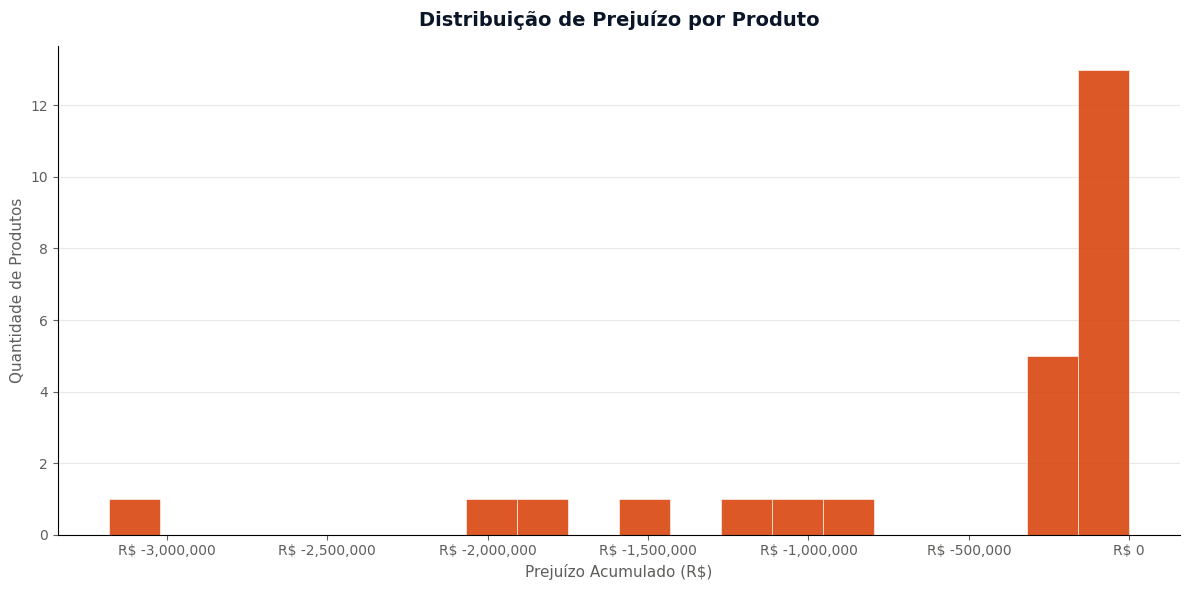

In [16]:
# Buscar todos os produtos com prejuízo (sem limite de 10)
query_dist = """
SELECT
    ROUND(SUM(total) - SUM(custo_atual_usd * qtd * 5.0), 2) AS lucro_prejuizo
FROM base_completa
WHERE custo_atual_usd IS NOT NULL
GROUP BY id_product
HAVING lucro_prejuizo < 0
"""
df_dist = pd.read_sql(query_dist, conn)

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_facecolor("white")
fig.patch.set_facecolor("white")

ax.hist(
    df_dist["lucro_prejuizo"],
    bins=20,
    color="#D83B01",
    edgecolor="white",
    linewidth=0.5,
    alpha=0.85
)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))
ax.yaxis.grid(True, color="#E8E8E8", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(labelsize=10, colors="#605E5C")

ax.set_title("Distribuição de Prejuízo por Produto",
             fontsize=14, fontweight="bold", color="#0A1628", pad=15)
ax.set_xlabel("Prejuízo Acumulado (R$)", fontsize=11, color="#605E5C")
ax.set_ylabel("Quantidade de Produtos", fontsize=11, color="#605E5C")

plt.tight_layout()
plt.savefig("distribuicao_prejuizo.png", dpi=150, bbox_inches="tight")
plt.show()

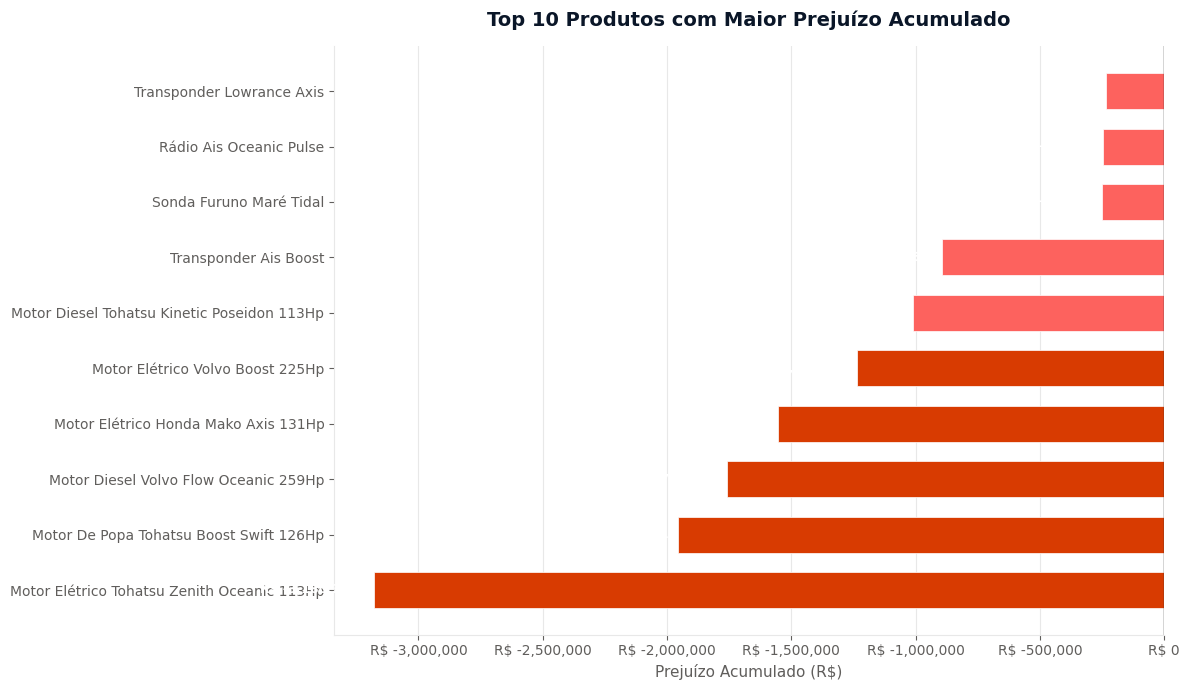

In [25]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

# ── Buscar dados do banco ──────────────────────────────
query = """
SELECT
    name AS produto,
    actual_category AS categoria,
    ROUND(SUM(total) - SUM(custo_atual_usd * qtd * 5.0), 2) AS lucro_prejuizo

FROM base_completa
WHERE custo_atual_usd IS NOT NULL
GROUP BY id_product, name, actual_category
HAVING lucro_prejuizo < 0
ORDER BY lucro_prejuizo ASC
LIMIT 10
"""

df_prej = pd.read_sql(query, conn)

# ── Gráfico ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))
ax.set_facecolor("white")
fig.patch.set_facecolor("white")

# Cores por intensidade de prejuízo
cores = ["#D83B01" if v < df_prej["lucro_prejuizo"].mean()
         else "#FD625E"
         for v in df_prej["lucro_prejuizo"]]

bars = ax.barh(
    df_prej["produto"],
    df_prej["lucro_prejuizo"],
    color=cores,
    edgecolor="white",
    linewidth=0.5,
    height=0.65
)

# Rótulos com valor no final de cada barra
for bar, val in zip(bars, df_prej["lucro_prejuizo"]):
    ax.text(
        val - abs(val) * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"R$ {val:,.0f}",
        va="center", ha="right",
        fontsize=9, color="white", fontweight="bold"
    )

# Grade
ax.xaxis.grid(True, color="#E8E8E8", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

# Eixo X em R$
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))

# Linha zero
ax.axvline(0, color="#333333", linewidth=1)

# Bordas
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#E8E8E8")
ax.spines["bottom"].set_color("#E8E8E8")
ax.tick_params(axis="both", labelsize=10, colors="#605E5C")

# Títulos
ax.set_title("Top 10 Produtos com Maior Prejuízo Acumulado",
             fontsize=14, fontweight="bold", color="#0A1628", pad=15)
ax.set_xlabel("Prejuízo Acumulado (R$)", fontsize=11, color="#605E5C")

plt.tight_layout()
plt.savefig("ranking_prejuizo.png", dpi=150, bbox_inches="tight")
plt.show()

In [26]:
query = """
SELECT
    CASE CAST(strftime('%w', sale_date) AS INTEGER)
        WHEN 0 THEN '7-Domingo'
        WHEN 1 THEN '1-Segunda'
        WHEN 2 THEN '2-Terca'
        WHEN 3 THEN '3-Quarta'
        WHEN 4 THEN '4-Quinta'
        WHEN 5 THEN '5-Sexta'
        WHEN 6 THEN '6-Sabado'
    END AS dia_semana,
    ROUND(AVG(total), 2) AS media_vendas,
    COUNT(*) AS total_vendas,
    SUM(CASE WHEN total > 0 THEN 1 ELSE 0 END) AS dias_com_venda

FROM base_completa
GROUP BY dia_semana
ORDER BY dia_semana
"""

df_dias = pd.read_sql(query, conn)

# Limpar o prefixo numérico usado para ordenação
df_dias["dia_label"] = df_dias["dia_semana"].str[2:]
print(df_dias)

  dia_semana  media_vendas  total_vendas  dias_com_venda dia_label
0  1-Segunda     257494.31          1413            1413   Segunda
1    2-Terca     261565.80          1456            1456     Terca
2   3-Quarta     260942.25          1409            1409    Quarta
3   4-Quinta     266333.46          1416            1416    Quinta
4    5-Sexta     267562.57          1444            1444     Sexta
5   6-Sabado     272911.04          1414            1414    Sabado
6  7-Domingo     259529.32          1343            1343   Domingo


In [27]:
query = """
WITH todos_dias AS (
    SELECT '1-Segunda' AS dia_semana UNION ALL
    SELECT '2-Terca'   UNION ALL
    SELECT '3-Quarta'  UNION ALL
    SELECT '4-Quinta'  UNION ALL
    SELECT '5-Sexta'   UNION ALL
    SELECT '6-Sabado'  UNION ALL
    SELECT '7-Domingo'
),
vendas_por_dia AS (
    SELECT
        CASE CAST(strftime('%w', sale_date) AS INTEGER)
            WHEN 0 THEN '7-Domingo'
            WHEN 1 THEN '1-Segunda'
            WHEN 2 THEN '2-Terca'
            WHEN 3 THEN '3-Quarta'
            WHEN 4 THEN '4-Quinta'
            WHEN 5 THEN '5-Sexta'
            WHEN 6 THEN '6-Sabado'
        END AS dia_semana,
        COUNT(DISTINCT DATE(sale_date)) AS dias_com_venda,
        SUM(total) AS total_vendas
    FROM base_completa
    GROUP BY dia_semana
)

SELECT
    t.dia_semana,
    COALESCE(v.dias_com_venda, 0) AS dias_com_venda,
    COALESCE(v.total_vendas, 0) AS total_vendas,
    ROUND(
        COALESCE(v.total_vendas, 0) * 1.0 / (
            SELECT COUNT(DISTINCT DATE(sale_date))
            FROM base_completa
            WHERE CAST(strftime('%w', sale_date) AS INTEGER) =
                CASE t.dia_semana
                    WHEN '1-Segunda' THEN 1
                    WHEN '2-Terca'   THEN 2
                    WHEN '3-Quarta'  THEN 3
                    WHEN '4-Quinta'  THEN 4
                    WHEN '5-Sexta'   THEN 5
                    WHEN '6-Sabado'  THEN 6
                    WHEN '7-Domingo' THEN 0
                END
        ), 2
    ) AS media_com_dias_sem_venda

FROM todos_dias t
LEFT JOIN vendas_por_dia v ON t.dia_semana = v.dia_semana
ORDER BY t.dia_semana
"""

df_q6 = pd.read_sql(query, conn)
df_q6["dia_label"] = df_q6["dia_semana"].str[2:]

print("QUESTÃO 6 — Vendas Médias por Dia da Semana (com dias sem venda)")
print(df_q6[["dia_label", "dias_com_venda", "total_vendas", "media_com_dias_sem_venda"]].to_string(index=False))

QUESTÃO 6 — Vendas Médias por Dia da Semana (com dias sem venda)
dia_label  dias_com_venda  total_vendas  media_com_dias_sem_venda
  Segunda             103  363839459.90                3532421.94
    Terca             103  380839805.20                3697473.84
   Quarta             104  367667625.15                3535265.63
   Quinta             104  377128174.15                3626232.44
    Sexta             104  386360354.55                3715003.41
   Sabado             104  385896217.15                3710540.55
  Domingo             103  348547874.60                3383959.95


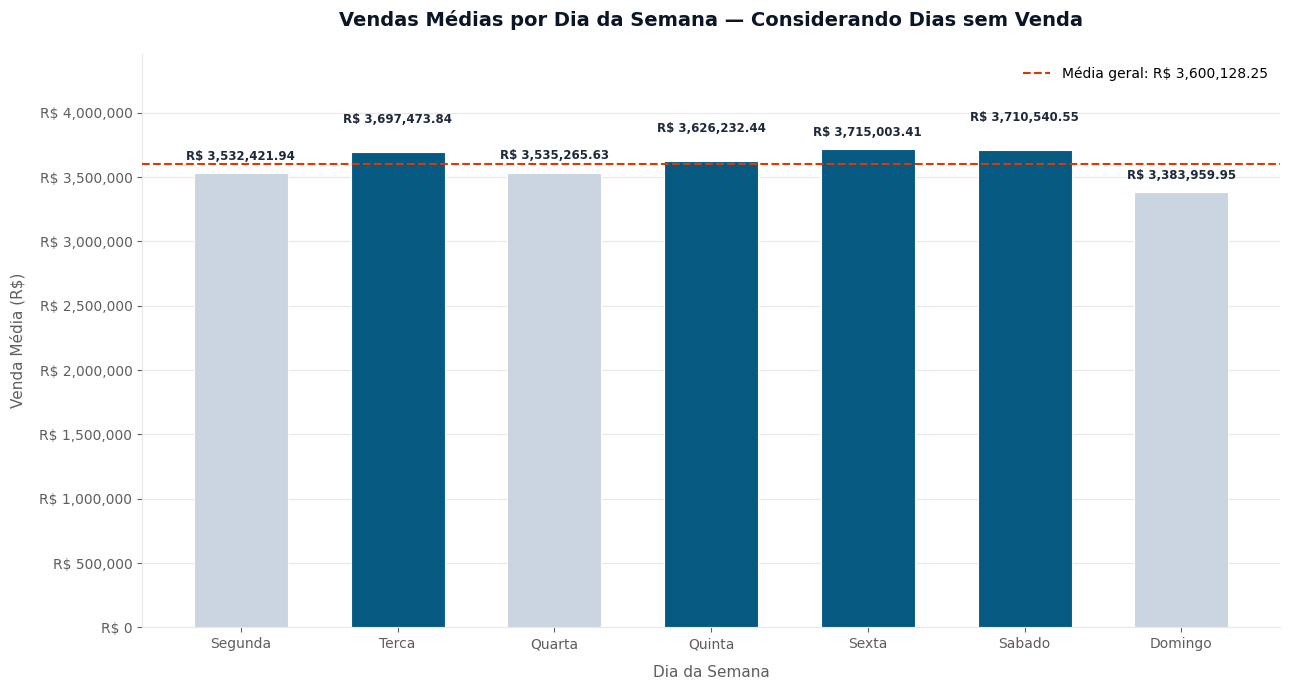

In [30]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(13, 7))
ax.set_facecolor("white")
fig.patch.set_facecolor("white")

# Reordenar corretamente
ordem = ["Segunda", "Terca", "Quarta", "Quinta", "Sexta", "Sabado", "Domingo"]
df_q6 = df_q6.set_index("dia_label").reindex(ordem).reset_index()

media_geral = df_q6["media_com_dias_sem_venda"].mean()

# Cores corrigidas
cores = [
    "#F59E0B" if v >= media_geral * 1.05   # destaque amarelo — bem acima da média
    else "#065A82" if v >= media_geral      # azul — acima ou na média
    else "#CBD5E1"                          # cinza — abaixo da média
    for v in df_q6["media_com_dias_sem_venda"]
]

bars = ax.bar(
    df_q6["dia_label"],
    df_q6["media_com_dias_sem_venda"],
    color=cores,
    edgecolor="white",
    linewidth=0.8,
    width=0.6,
    zorder=3
)

# Rótulos corrigidos — alternando posição para evitar sobreposição
for i, (bar, val) in enumerate(zip(bars, df_q6["media_com_dias_sem_venda"])):
    # Alterna: pares sobem mais, ímpares sobem menos
    offset = 80000 if i % 2 == 0 else 200000
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + offset,
        f"R$ {val:,.2f}",
        ha="center", va="bottom",
        fontsize=8.5, color="#1E293B", fontweight="bold"
    )

# Linha de média geral
ax.axhline(
    media_geral,
    color="#D83B01", linewidth=1.5,
    linestyle="--", zorder=4,
    label=f"Média geral: R$ {media_geral:,.2f}"
)

# Grade e estilo
ax.yaxis.grid(True, color="#E8E8E8", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))

# Margem superior para os rótulos não cortarem
ax.set_ylim(0, df_q6["media_com_dias_sem_venda"].max() * 1.20)

# Bordas
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#E8E8E8")
ax.spines["bottom"].set_color("#E8E8E8")
ax.tick_params(labelsize=10, colors="#605E5C")

# Títulos
ax.set_title(
    "Vendas Médias por Dia da Semana — Considerando Dias sem Venda",
    fontsize=14, fontweight="bold", color="#0A1628", pad=20
)
ax.set_xlabel("Dia da Semana", fontsize=11, color="#605E5C", labelpad=10)
ax.set_ylabel("Venda Média (R$)", fontsize=11, color="#605E5C", labelpad=10)
ax.legend(frameon=False, fontsize=10, loc="upper right")

plt.tight_layout()
plt.savefig("questao6_vendas_dia_semana.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
conn.close()
print("Conexão fechada!")

Conexão fechada!
